# Simple E-I Pop



In [58]:
import numpy as np
import pandas as pd
import nest
import nest.raster_plot
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sim_utils import *

# Set UP

In [59]:
def sim_1(sim_params, neuron_dicts, syn_params, current_params):
    nest.ResetKernel()
    # Make simulation with higher resolution
    nest.SetKernelStatus({"resolution": .001})

    # Create AdEx neuron
    neuron1 = nest.Create("aeif_cond_exp", n=sim_params["n_ex"], params=neuron_dicts["TC"])
    neuron2 = nest.Create("aeif_cond_exp", n=sim_params["n_inh"], params=neuron_dicts["RE"])

    # Create a poisson generator
    step_current = nest.Create("step_current_generator", params=current_params)

    #sni
    #  Connect the step current generator to the neuron
    #nest.Connect(step_current, neuron1)
    nest.Connect(step_current, neuron1)
    nest.Connect(neuron1, neuron2, "all_to_all",syn_spec={'weight': syn_params["w_e"]})
    nest.Connect(neuron2, neuron1, "all_to_all",syn_spec={'weight': syn_params["w_i"]})

    # Create a voltmeter to record the membrane potential
    voltmeter1 = nest.Create("voltmeter")
    voltmeter2 = nest.Create("voltmeter")
    spikemeter1 = nest.Create("spike_recorder")
    spikemeter2 = nest.Create("spike_recorder")

    # Connect the voltmeter to the neuron
    nest.Connect(voltmeter1, neuron1)
    nest.Connect(voltmeter2, neuron2)

    nest.Connect(neuron1, spikemeter1)
    nest.Connect(neuron2, spikemeter2)

    nest.Simulate(1000.0)
    

    return {
        "voltmeters": [voltmeter1, voltmeter2],
        "spikemeters": [spikemeter1, spikemeter2]
    }


# Initial_Params

In [60]:
data = {
    "neuron_type": [ "TC", "RE"],
    "C_m": [1250, 1250], # pF
    "t_ref": [ 2.5, 2.5], # ms
    "E_L": [ -60, -60], # mV
    "Delta_T": [ 2.5, 2.5], # mV
    "V_th": [ -55, -50], # mV
    "V_reset": [ -60, -60],    
    "g_L": [ 50, 50],
    "a": [ 300, 400], # nS
    "b": [ 0, 20], # pA
    "tau_w": [ 600, 600],
    "I_e": [ 0, 0],
    "V_m": [ -60, -60],
    "V_peak": [20,20],# mV
    "I_e": [0,0],               # pA
    "V_m": [-60.0,-60.0],
    "tau_syn_ex": [ 5, 5],
    "tau_syn_in": [ 18, 18],
}

current_params = { "amplitude_times": [50, 100], "amplitude_values": [1000, 0.0]}
neuron_dicts = create_neuron_dicts(data)
sim_params = {
    "resolution": 0.001,
    "simtime": 1000.0,
    "n_inh": 1,
    "n_ex": 1,
}
syn_params = {
    "w_e": 700.0,  # weight of excitatory connection in nS
    "w_i": -1000.0,  # weight of inhibitory connection in nS
}




In [61]:
neuron_dicts["TC"]

{'C_m': 1250,
 't_ref': 2.5,
 'E_L': -60,
 'Delta_T': 2.5,
 'V_th': -55,
 'V_reset': -60,
 'g_L': 50,
 'a': 300,
 'b': 0,
 'tau_w': 600,
 'I_e': 0,
 'V_m': -60.0,
 'V_peak': 20,
 'tau_syn_ex': 5,
 'tau_syn_in': 18}

# Simulate and Plot


Mar 27 12:12:10 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 27 12:12:10 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Mar 27 12:12:10 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 27 12:12:11 SimulationManager::run [Info]: 
    Simulation finished.


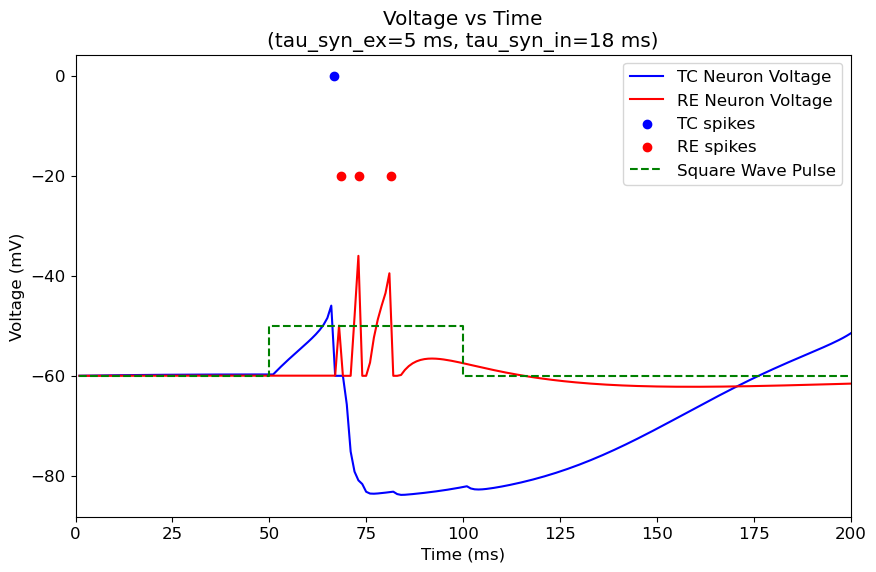

In [62]:
# Simulate and get the output
sim_output = sim_1(sim_params, neuron_dicts, syn_params, current_params)

# Extract voltmeter and spikemeter data
voltmeter1_data = nest.GetStatus(sim_output["voltmeters"][0])[0]
voltmeter2_data = nest.GetStatus(sim_output["voltmeters"][1])[0]
spikemeter1_data = nest.GetStatus(sim_output["spikemeters"][0])[0]
spikemeter2_data = nest.GetStatus(sim_output["spikemeters"][1])[0]

# Extract times and voltages for TC and RE neurons
TC_times = voltmeter1_data["events"]["times"]
TC_voltages = voltmeter1_data["events"]["V_m"]
RE_times = voltmeter2_data["events"]["times"]
RE_voltages = voltmeter2_data["events"]["V_m"]

# Extract the spike times and ids
TC_spike_times = spikemeter1_data["events"]["times"]
TC_spike_ids = spikemeter1_data["events"]["senders"]
RE_spike_times = spikemeter2_data["events"]["times"]
RE_spike_ids = spikemeter2_data["events"]["senders"]

# Plot the voltage traces
plt.figure(figsize=(10, 6))
plt.plot(TC_times, TC_voltages, label="TC Neuron Voltage", color="blue")
plt.plot(RE_times, RE_voltages, label="RE Neuron Voltage", color="red")
plt.scatter(TC_spike_times, [0]*len(TC_spike_times), color="blue", label="TC spikes")
plt.scatter(RE_spike_times, [-20]*len(RE_spike_times), color="red", label="RE spikes")

# Add a square wave pulse
pulse_start = 50  # Start time of the pulse
pulse_end = 100   # End time of the pulse
pulse_height = 10  # Height of the square wave

# Create the square wave data
pulse_times = [TC_times[0], pulse_start, pulse_start, pulse_end, pulse_end, TC_times[-1]]
pulse_voltages = [TC_voltages[0], TC_voltages[0], TC_voltages[0] + pulse_height, TC_voltages[0] + pulse_height, TC_voltages[0], TC_voltages[0]]

# Plot the square wave
plt.plot(pulse_times, pulse_voltages, label="Square Wave Pulse", linestyle="--", color="green")

# Add labels, title, and legend
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"Voltage vs Time\n(tau_syn_ex={neuron_dicts['TC']['tau_syn_ex']} ms, tau_syn_in={neuron_dicts['RE']['tau_syn_in']} ms)")
plt.xlim(0, 200)
plt.legend()
plt.show()

# Sweep

In [63]:
v1_array = []
ex_rate_array = []
inh_rate_array = []
tau_syn_ex_array = np.round(np.linspace(2, 6, 10), 1)
tau_syn_in_array = np.round(np.linspace(15, 20, 5), 1)

for i in tau_syn_ex_array:
    for k in tau_syn_in_array:
        neuron_dicts['TC']["tau_syn_ex"] = i
        neuron_dicts['RE']["tau_syn_ex"] = i
        neuron_dicts['TC']["tau_syn_in"] = k
        neuron_dicts['RE']["tau_syn_in"] = k
        
        sim_output = sim_1(sim_params, neuron_dicts, syn_params, current_params)

        # Extract voltmeter and spikemeter data
        voltmeter1_data = nest.GetStatus(sim_output["voltmeters"][0])[0]
        voltmeter2_data = nest.GetStatus(sim_output["voltmeters"][1])[0]
        spikemeter1_data = nest.GetStatus(sim_output["spikemeters"][0])[0]
        spikemeter2_data = nest.GetStatus(sim_output["spikemeters"][1])[0]

        # Extract times and voltages for TC and RE neurons
        TC_times = voltmeter1_data["events"]["times"]
        TC_voltages = voltmeter1_data["events"]["V_m"]
        RE_times = voltmeter2_data["events"]["times"]
        RE_voltages = voltmeter2_data["events"]["V_m"]

        # Extract the spike times and ids
        TC_spike_times = spikemeter1_data["events"]["times"]
        TC_spike_ids = spikemeter1_data["events"]["senders"]
        RE_spike_times = spikemeter2_data["events"]["times"]
        RE_spike_ids = spikemeter2_data["events"]["senders"]

        spikes = len(TC_spike_ids)
        spikes2 = len(RE_spike_ids)
        
        rate = spikes/1
        rate2 = spikes2/1
        ex_rate_array.append(rate)
        inh_rate_array.append(rate2)
        data= {"times": TC_times, "voltages": TC_voltages, "times2": RE_times, "voltages2": RE_voltages, "tau_syn_ex": i, "tau_syn_in": k}
        v1_array.append(data)






Mar 27 16:42:48 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 27 16:42:48 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Mar 27 16:42:48 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 27 16:42:50 SimulationManager::run [Info]: 
    Simulation finished.

Mar 27 16:42:50 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 27 16:42:50 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Mar 27 16:42:50 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 27 16:42:51 SimulationManager::run [Info]: 
    Simulation finished.

Mar 27 16:42:51 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms

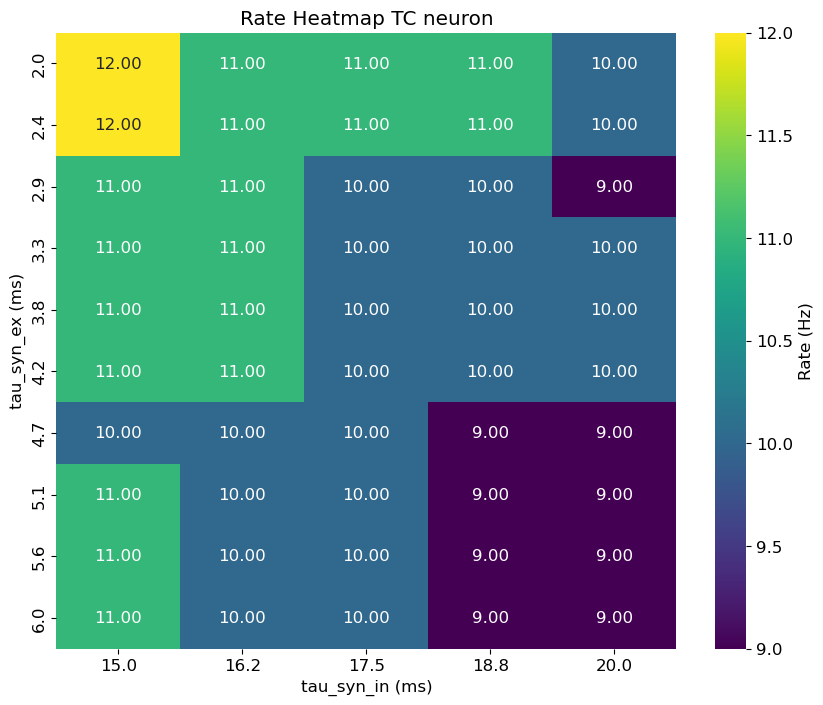

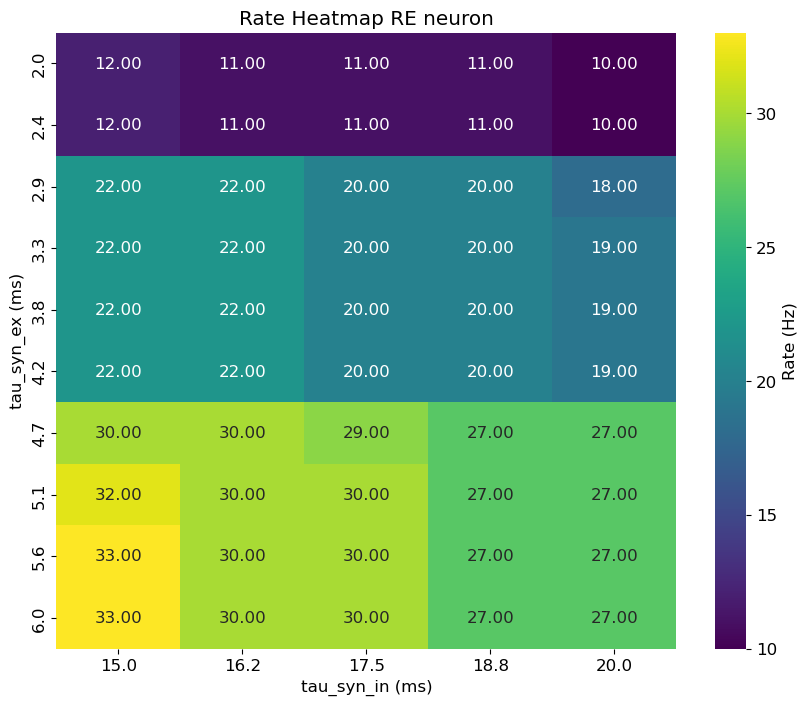

In [52]:
def plot_rate_heatmap(rate_array, tau_syn_ex_array, tau_syn_in_array, title="Rate Heatmap TC neuron", font_size=12, cbar_label="Rate (Hz)"):
    # Reshape the rate array into a 2D array for the heatmap
    rate_matrix = np.array(rate_array).reshape(len(tau_syn_ex_array), len(tau_syn_in_array))
    
    # Set font size globally
    plt.rc('font', size=font_size)
    
    # Create a heatmap using seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(rate_matrix, annot=True, fmt=".2f", xticklabels=tau_syn_in_array, yticklabels=tau_syn_ex_array, cmap="viridis", 
                annot_kws={"size": font_size}, cbar_kws={"label": cbar_label})
    plt.xlabel("tau_syn_in (ms)")
    plt.ylabel("tau_syn_ex (ms)")
    plt.title(title)
    plt.show()

plot_rate_heatmap(ex_rate_array, tau_syn_ex_array, tau_syn_in_array, font_size=12,title="Rate Heatmap TC neuron", cbar_label="Rate (Hz)")
plot_rate_heatmap(inh_rate_array, tau_syn_ex_array, tau_syn_in_array, font_size=12,title="Rate Heatmap RE neuron", cbar_label="Rate (Hz)")

In [ ]:
x_plots = len(tau_syn_ex_array)
fig, axes = plt.subplots(1, x_plots, figsize=(20, 5))
fig.suptitle("Voltage vs Time")

# If there's only one subplot, `axes` will not be an array, so we need to handle that case
if x_plots == 1:
    axes = [axes]

for i, tau_syn_ex in enumerate(tau_syn_ex_array):
    ax = axes[i]
    k = -20
    yticks = []
    ytick_labels = []
    for data in v1_array:
        k = k + 20
        if data["tau_syn_ex"] == tau_syn_ex:
            ax.plot(data["times"], data["voltages"] + k, label=f"TC tau_syn_in: {data['tau_syn_in']}")
            ax.plot(data["times2"], data["voltages2"] + k, label=f"RE tau_syn_in: {data['tau_syn_in']}")
            yticks.append(k-60)
            ytick_labels.append(round(data["tau_syn_in"]))
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_ylabel("tau_syn_in(ms)")
    ax.set_xlabel("Time (ms)")
    ax.set_title(f"tau_syn_ex: {tau_syn_ex} (ms)")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
plt.show()


# Parameter Sweep for W

In [100]:
from itertools import product

def parameter_sweep_multi(param_sweep_dict, sim_params, neuron_dicts, syn_params, current_params):
    """
    Perform a parameter sweep for multiple parameters.

    Args:
        param_sweep_dict (dict): A dictionary where keys are parameter names (str) and values are lists of values to sweep.
        sim_params (dict): Simulation parameters.
        neuron_dicts (dict): Neuron parameter dictionaries.
        syn_params (dict): Synapse parameters.
        current_params (dict): Current parameters.

    Returns:
        list: A list of dictionaries containing the results for each parameter combination.
    """

    # Generate all combinations of parameter values
    param_names = list(param_sweep_dict.keys())
    param_combinations = list(product(*param_sweep_dict.values()))

    output_array = []

    for param_values in param_combinations:
        # Update parameters
        for param_name, param_value in zip(param_names, param_values):
            # Update the appropriate dictionary based on the parameter name
            if param_name in syn_params:
                syn_params[param_name] = param_value
            elif param_name in neuron_dicts["TC"]:
                neuron_dicts["TC"][param_name] = param_value
                neuron_dicts["RE"][param_name] = param_value
            elif param_name in current_params:
                current_params[param_name] = param_value
            elif param_name in sim_params:
                sim_params[param_name] = param_value

        # Simulate
        sim_output = sim_1(sim_params, neuron_dicts, syn_params, current_params)

        # Extract voltmeter and spikemeter data
        voltmeter1_data = nest.GetStatus(sim_output["voltmeters"][0])[0]
        voltmeter2_data = nest.GetStatus(sim_output["voltmeters"][1])[0]
        spikemeter1_data = nest.GetStatus(sim_output["spikemeters"][0])[0]
        spikemeter2_data = nest.GetStatus(sim_output["spikemeters"][1])[0]

        # Extract times and voltages for TC and RE neurons
        TC_times = voltmeter1_data["events"]["times"]
        TC_voltages = voltmeter1_data["events"]["V_m"]
        RE_times = voltmeter2_data["events"]["times"]
        RE_voltages = voltmeter2_data["events"]["V_m"]

        # Extract the spike times and ids
        TC_spike_times = spikemeter1_data["events"]["times"]
        TC_spike_ids = spikemeter1_data["events"]["senders"]
        RE_spike_times = spikemeter2_data["events"]["times"]
        RE_spike_ids = spikemeter2_data["events"]["senders"]

        data = {
            "params": dict(zip(param_names, param_values)),
            "TC_times": TC_times,
            "TC_voltages": TC_voltages,
            "TC_spike_times": TC_spike_times,
            "TC_spike_ids": TC_spike_ids,
            "RE_times": RE_times,
            "RE_voltages": RE_voltages,
            "RE_spike_times": RE_spike_times,
            "RE_spike_ids": RE_spike_ids
        }
        output_array.append(data)

    return output_array

# Example usage
param_sweep_dict = {
    "w_e": np.linspace(10, 100, 10),  # Sweep synaptic weight
}

output_array = parameter_sweep_multi(param_sweep_dict, sim_params, neuron_dicts, syn_params, current_params)


Mar 27 17:29:32 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 27 17:29:32 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Mar 27 17:29:32 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 27 17:29:33 SimulationManager::run [Info]: 
    Simulation finished.

Mar 27 17:29:33 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Mar 27 17:29:33 NodeManager::prepare_nodes [Info]: 
    Preparing 7 nodes for simulation.

Mar 27 17:29:33 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 7
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

Mar 27 17:29:35 SimulationManager::run [Info]: 
    Simulation finished.

Mar 27 17:29:35 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms

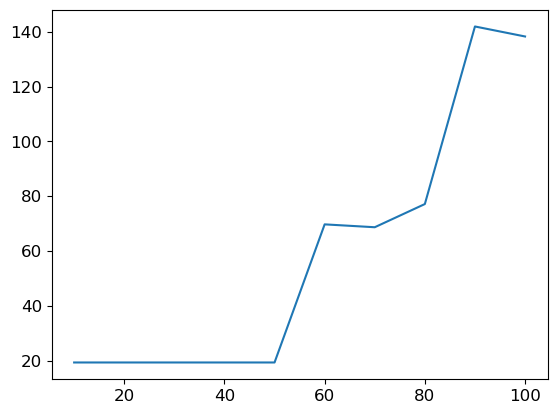

In [103]:
isi_averages=[]
for i in output_array:
    isi_averages.append(np.mean(np.diff(i["TC_spike_times"])))
fig, ax = plt.subplots()
plt.plot(param_sweep_dict["w_e"], isi_averages)



/home/hector/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:Mean of empty slice.
/home/hector/miniconda3/envs/neuro_sim/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning:invalid value encountered in scalar divide


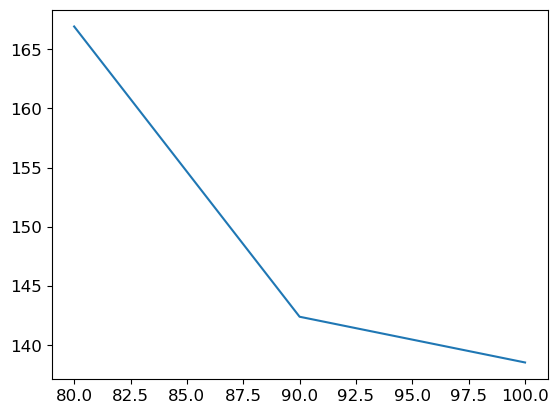

In [104]:
isi_averages=[]
for i in output_array:
    isi_averages.append(np.mean(np.diff(i["RE_spike_times"])))
fig, ax = plt.subplots()
plt.plot(param_sweep_dict["w_e"], isi_averages)
